# Versao 9 - Visao Geral Dos Dados

## Objetivo deste notebook

A `versao9` mantem o problema de classificacao multiclasse do `3W`, no qual cada arquivo `parquet` representa uma amostra rotulada entre as classes `0` e `9`.

O que muda agora e a hipotese do modelo: queremos testar uma arquitetura `LSTM` mais forte, capaz de usar ao mesmo tempo:

- a sequencia temporal reamostrada (`X_seq`);
- o vetor de atributos agregados (`X_tab`);
- a separacao entre sinais continuos e sinais de estado;
- uma leitura hierarquica em janelas.

Em termos simples, a `versao9` nasce com uma pergunta muito direta:

> uma `LSTM` hibrida, que enxergue a serie por janelas e ainda receba informacao tabular global, consegue se aproximar ou superar a baseline?

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao9" else ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao5.pipeline_v5 import summarize_dataset_inventory
from versao9.pipeline_v9 import (
    BASE_TARGET_COLUMNS,
    CANDIDATE_FEATURE_COLUMNS,
    clean_base_frame,
    discover_series_manifest,
    load_attribute_catalog,
    load_event_catalog,
)

DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"
manifest = discover_series_manifest(DATASET_ROOT)
attribute_catalog = load_attribute_catalog(DATASET_ROOT)
event_catalog = load_event_catalog(DATASET_ROOT)
inventory = summarize_dataset_inventory(DATASET_ROOT)

manifest.head()

,class_label,well_name,start_token,series_id,source_type,file_path,class_label_int
0,0,WELL-00001,20170201010207,0__WELL-00001_20170201010207,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
1,0,WELL-00001,20170201060114,0__WELL-00001_20170201060114,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
2,0,WELL-00001,20170201110124,0__WELL-00001_20170201110124,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
3,0,WELL-00001,20170201160311,0__WELL-00001_20170201160311,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0
4,0,WELL-00001,20170201210228,0__WELL-00001_20170201210228,well,/home/tiagoriosrocha/Desktop/lstm-w3/3W/datase...,0


## O que continua igual

Mesmo com a nova arquitetura, alguns elementos do projeto permanecem estaveis:

- o dataset continua sendo o `3W`;
- o rotulo continua vindo da pasta da amostra;
- a unidade amostral continua sendo a serie completa;
- a comparacao com `RandomForest` e `XGBoost` continua sendo obrigatoria.

In [3]:
display(inventory["overview"])
display(inventory["class_distribution"])
display(inventory["source_distribution"])

,estatistica,valor
0,arquivos,2.228000e+03
1,classes_distintas,1.000000e+01
2,pocos_distintos,4.200000e+01
3,tipos_de_origem,3.000000e+00
4,linhas_totais,7.658732e+07
5,mediana_linhas_por_serie,2.699900e+04
6,media_linhas_por_serie,3.437492e+04


,class_label,arquivos
0,0,594
1,1,128
2,2,38
3,3,106
4,4,343
5,5,450
6,6,221
7,7,46
8,8,95
9,9,207


,source_type,arquivos
0,drawn,20
1,simulated,1089
2,well,1119


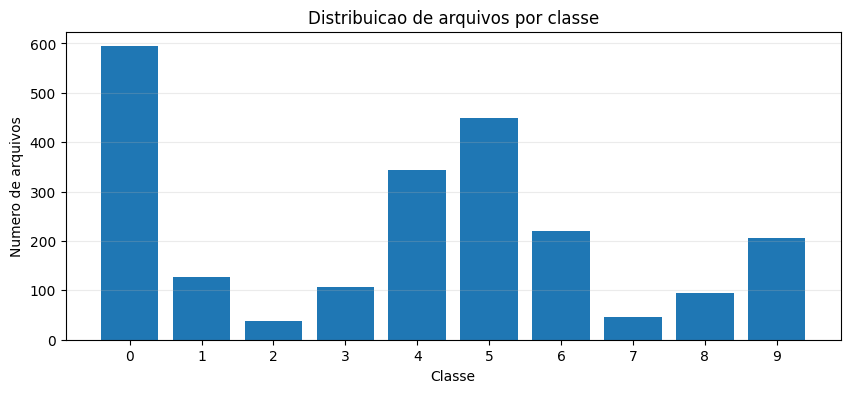

In [4]:
class_df = inventory["class_distribution"].copy()

plt.figure(figsize=(10, 4))
plt.bar(class_df["class_label"].astype(str), class_df["arquivos"])
plt.title("Distribuicao de arquivos por classe")
plt.xlabel("Classe")
plt.ylabel("Numero de arquivos")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Por que a versao9 e diferente?

O `RandomForest` e o `XGBoost` continuam fortes porque recebem uma representacao tabular extremamente discriminativa. Logo, uma simples `LSTM` sobre a sequencia reamostrada pode estar em desvantagem informacional.

A `versao9` tenta reduzir essa desvantagem de tres formas:

1. dividir a serie em janelas menores, para destacar padroes locais;
2. tratar sinais continuos e sinais discretos em ramos separados;
3. fundir o embedding temporal com `X_tab`.

In [5]:
print("Colunas candidatas para modelagem:")
for column_name in CANDIDATE_FEATURE_COLUMNS:
    print(" -", column_name)

print("\nCatalogo oficial de atributos:")
display(attribute_catalog)
print("\nCatalogo oficial de classes:")
display(event_catalog)

Colunas candidatas para modelagem:
 - P-ANULAR
 - P-JUS-CKGL
 - P-MON-CKP
 - P-TPT
 - T-JUS-CKP
 - T-TPT
 - ESTADO-DHSV
 - ESTADO-M1
 - ESTADO-M2
 - ESTADO-PXO
 - ESTADO-SDV-GL
 - ESTADO-SDV-P
 - ESTADO-W1
 - ESTADO-W2
 - ESTADO-XO
 - P-PDG
 - QGL
 - T-PDG

Catalogo oficial de atributos:


,atributo,papel_no_pipeline,descricao_oficial
0,timestamp,metadado,Instant at which observation was generated
1,ABER-CKGL,metadado,Opening of the GLCK (gas lift choke) [%]
2,ABER-CKP,metadado,Opening of the PCK (production choke) [%]
3,ESTADO-DHSV,estado_discreto,"State of the DHSV (downhole safety valve) [0, ..."
4,ESTADO-M1,estado_discreto,"State of the PMV (production master valve) [0,..."
5,ESTADO-M2,estado_discreto,"State of the AMV (annulus master valve) [0, 0...."
6,ESTADO-PXO,estado_discreto,"State of the PXO (pig-crossover) valve [0, 0.5..."
7,ESTADO-SDV-GL,estado_discreto,"State of the gas lift SDV (shutdown valve) [0,..."
8,ESTADO-SDV-P,estado_discreto,State of the production SDV (shutdown valve) [...
9,ESTADO-W1,estado_discreto,"State of the PWV (production wing valve) [0, 0..."



Catalogo oficial de classes:


,class_label,event_name,description,transient_event
0,0,NORMAL,Normal Operation,False
1,1,ABRUPT_INCREASE_OF_BSW,Abrupt Increase of BSW,True
2,2,SPURIOUS_CLOSURE_OF_DHSV,Spurious Closure of DHSV,True
3,3,SEVERE_SLUGGING,Severe Slugging,False
4,4,FLOW_INSTABILITY,Flow Instability,False
5,5,RAPID_PRODUCTIVITY_LOSS,Rapid Productivity Loss,True
6,6,QUICK_RESTRICTION_IN_PCK,Quick Restriction in PCK,True
7,7,SCALING_IN_PCK,Scaling in PCK,True
8,8,HYDRATE_IN_PRODUCTION_LINE,Hydrate in Production Line,True
9,9,HYDRATE_IN_SERVICE_LINE,Hydrate in Service Line,True


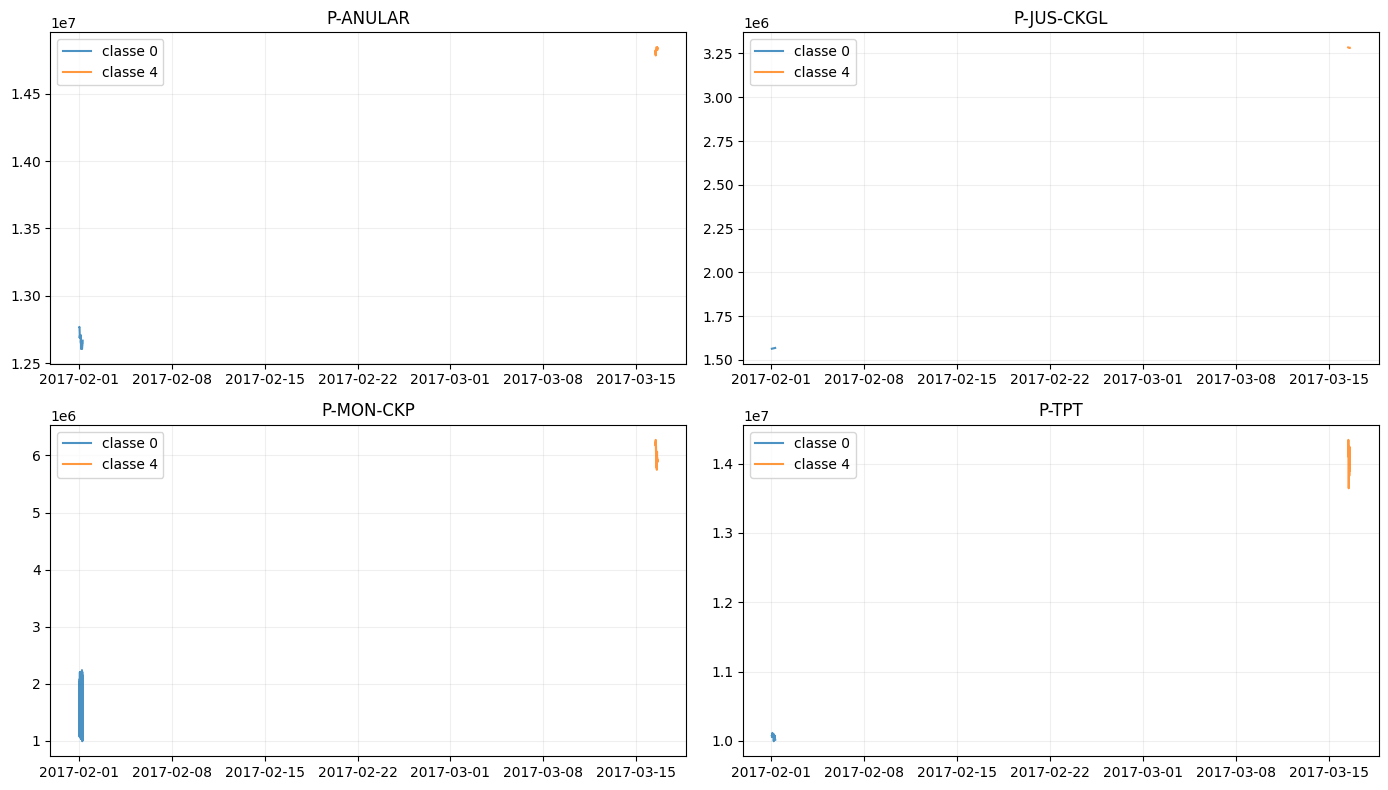

In [6]:
sample_normal = manifest.loc[manifest["class_label_int"] == 0].iloc[0]
sample_fault = manifest.loc[manifest["class_label_int"] == 4].iloc[0]

clean_normal = clean_base_frame(
    sample_normal["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in CANDIDATE_FEATURE_COLUMNS if c not in BASE_TARGET_COLUMNS],
)
clean_fault = clean_base_frame(
    sample_fault["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in CANDIDATE_FEATURE_COLUMNS if c not in BASE_TARGET_COLUMNS],
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, signal_name in zip(axes.ravel(), BASE_TARGET_COLUMNS[:4]):
    ax.plot(clean_normal["timestamp"], clean_normal[signal_name], label="classe 0", alpha=0.8)
    ax.plot(clean_fault["timestamp"], clean_fault[signal_name], label="classe 4", alpha=0.8)
    ax.set_title(signal_name)
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
plt.show()

## Fechamento do notebook

O proximo passo sera preparar os dados em um formato que permita:

- preservar a sequencia temporal;
- construir `X_tab`;
- organizar a leitura em janelas;
- manter a comparacao justa com as baselines tabulares.